<a href="https://colab.research.google.com/github/YoussefHassan4002/CODES/blob/main/waste_classification_model11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Waste Classification Model**

In this colab, we will be working on buidling a classification model by using VGG16 to classify different types of wastes into either organic or recyclable objects

# **Import**

In [ ]:
import os
import random
from copy import deepcopy
import torch
import torch.nn as nn
import torchvision
from torch import optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Check if GPU is available and if not change the runtime.

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('Using gpu: %s ' % torch.cuda.is_available())

Using gpu: True 


# **Download the dataset**
We download the full dataset from [Kaggle](https://www.kaggle.com/datasets/techsash/waste-classification-data/data) and upload to the goole drive to retrieve it

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("techsash/waste-classification-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Path to dataset files: /kaggle/input/waste-classification-data


# **Data Loading**

In [ ]:
import os
# Resolve DATASET folder: from kagglehub `path` (previous cell) or default cache
if 'path' in globals() and path is not None:
    data_dir = os.path.join(path, 'DATASET')
else:
    data_dir = os.path.join(
        os.path.expanduser('~'), '.cache', 'kagglehub', 'datasets',
        'techsash', 'waste-classification-data', 'versions', '1', 'DATASET',
    )
print('data_dir =', data_dir)

if os.path.isdir(data_dir):
    print(f"Directory '{data_dir}' exists.")
else:
    print(f"Directory '{data_dir}' does not exist. Run the kagglehub download cell first.")

if os.path.exists(data_dir):
    print('Files and directories within the path:')
    for item in os.listdir(data_dir):
        item_path = os.path.join(data_dir, item)
        print(f"- {item} (Directory: {os.path.isdir(item_path)})")


data_dir = /kaggle/input/waste-classification-data/DATASET
Directory '/kaggle/input/waste-classification-data/DATASET' exists.
Files and directories within the path:
- TEST (Directory: True)
- TRAIN (Directory: True)


In this step, we check each train and test files contain the images

In [ ]:
# check if files have images
for root, dirs, files in os.walk(data_dir):
    print(f"Directory: {root}")
    print(f"Subdirectories: {dirs}")
    print(f"Files: {files}")

Directory: /kaggle/input/waste-classification-data/DATASET
Subdirectories: ['TEST', 'TRAIN']
Files: []
Directory: /kaggle/input/waste-classification-data/DATASET/TEST
Subdirectories: ['R', 'O']
Files: []
Directory: /kaggle/input/waste-classification-data/DATASET/TEST/R
Subdirectories: []
Files: ['R_10683.jpg', 'R_10736.jpg', 'R_10489.jpg', 'R_10512.jpg', 'R_10975.jpg', 'R_10064.jpg', 'R_10281.jpg', 'R_10384.jpg', 'R_10986.jpg', 'R_10870.jpg', 'R_10786.jpg', 'R_10268.jpg', 'R_10760.jpg', 'R_10759.jpg', 'R_11008.jpg', 'R_10794.jpg', 'R_11080.jpg', 'R_11001.jpg', 'R_10460.jpg', 'R_10494.jpg', 'R_10637.jpg', 'R_10273.jpg', 'R_10358.jpg', 'R_10089.jpg', 'R_10608.jpg', 'R_10563.jpg', 'R_10701.jpg', 'R_11076.jpg', 'R_10574.jpg', 'R_10756.jpg', 'R_10660.jpg', 'R_10508.jpg', 'R_11090.jpg', 'R_10866.jpg', 'R_11047.jpg', 'R_10686.jpg', 'R_10133.jpg', 'R_10979.jpg', 'R_10381.jpg', 'R_10934.jpg', 'R_10581.jpg', 'R_10754.jpg', 'R_10083.jpg', 'R_10223.jpg', 'R_10316.jpg', 'R_10385.jpg', 'R_10556.jpg'

In [ ]:
# Reproducibility, transforms, and train/val split (80/20); train uses augmentation
from torchvision import models, transforms, datasets
from collections import Counter
import torch
import os
import random
import numpy as np

RANDOM_SEED = 42

def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.1, 0.1, 0.1, 0.02),
        transforms.ToTensor(),
        normalize,
    ]
)
eval_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize,
    ]
)


class TransformSubset(torch.utils.data.Dataset):
    # Subset of ImageFolder (transform=None) with per-split transform

    def __init__(self, image_folder, indices, transform):
        self.base = image_folder
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        img = self.base.loader(path)
        if self.transform is not None:
            img = self.transform(img)
        return img, label


train_root = os.path.join(data_dir, 'TRAIN')
train_full = datasets.ImageFolder(train_root, transform=None)

g = torch.Generator().manual_seed(RANDOM_SEED)
n = len(train_full)
train_size = int(0.8 * n)
val_size = n - train_size
train_part, val_part = random_split(train_full, [train_size, val_size], generator=g)

train_dataset = TransformSubset(train_full, train_part.indices, train_transform)
val_dataset = TransformSubset(train_full, val_part.indices, eval_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'TEST'), transform=eval_transform)

# Backward-compatible name for any cell that still references dsets
dsets = {
    'TRAIN': train_full,
    'TEST': test_dataset,
}

dset_sizes = {'TRAIN': n, 'TEST': len(test_dataset)}
dset_classes = train_full.classes

labels_train = [train_full.samples[i][1] for i in train_part.indices]
counts = Counter(labels_train)
c0, c1 = counts.get(0, 0), counts.get(1, 0)
if c0 == 0 or c1 == 0:
    class_weights = torch.tensor([1.0, 1.0], dtype=torch.float32)
else:
    class_weights = torch.tensor(
        [len(labels_train) / (2 * c0), len(labels_train) / (2 * c1)], dtype=torch.float32
    )
print('Class names:', dset_classes)
print('Class counts in train split:', dict(counts))
print('class_weights:', class_weights)


Class names: ['O', 'R']
Class counts in train split: {0: 10012, 1: 8039}
class_weights: tensor([0.9015, 1.1227])


normilize the images into the size of 224x224x3 and check that there should have TRAIN (22564) and TEST (2513)images

In [ ]:
# checking dataset size
len(dsets['TRAIN']), len(dsets['TEST'])

(22564, 2513)

# **Data loading and Batching**

here, we load the datasets in batches using Dataloader

In [ ]:
# Train/val split and transforms are defined in the previous cell. Sizes:
len(train_dataset), len(val_dataset), len(test_dataset)


(18051, 4513, 2513)

In [ ]:
BATCH_SIZE = 32
num_workers = 0
pin = torch.cuda.is_available()

loader_train = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=pin
)
loader_valid = torch.utils.data.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=pin
)
loader_test = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=pin
)
len(loader_train), len(loader_valid), len(loader_test)


(565, 142, 79)

# **Visualization**

In [ ]:
# A small function to display images:
def imshow(inp, title=None):
# Imshow for Tensor.
  inp = inp.numpy().transpose((1, 2, 0)) # modify dimensions
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  inp = np.clip(std * inp + mean, 0,1) # non-normalize
  plt.imshow(inp)
  if title is not None:
    plt.title(title)

Inputs shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


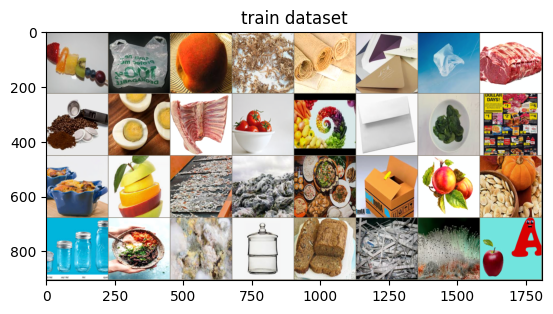

In [ ]:
# take a training batch and visualize the images from train dataset
inputs_try, labels_try = next(iter(loader_train))

# check shapes
print("Inputs shape:", inputs_try.shape)
print("Labels shape:", labels_try.shape)

# Make a grid from batch from the
out = torchvision.utils.make_grid(inputs_try)
imshow(out, title='train dataset')

Inputs shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


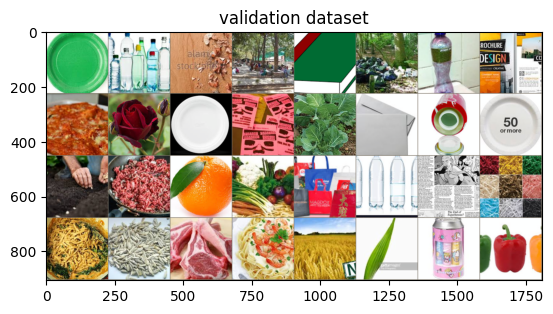

In [ ]:
# take a validation batch and visualize the images from validation dataset
inputs_try, labels_try = next(iter(loader_valid))

# check shapes
print("Inputs shape:", inputs_try.shape)
print("Labels shape:", labels_try.shape)

# Make a grid from batch
out = torchvision.utils.make_grid(inputs_try)
imshow(out, title='validation dataset')

Inputs shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


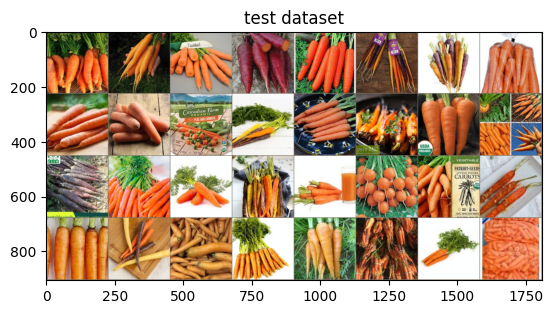

In [ ]:
# take a testing batch and visualize the images from test dataset
inputs_try, labels_try = next(iter(loader_test))

# check shapes
print("Inputs shape:", inputs_try.shape)
print("Labels shape:", labels_try.shape)

# Make a grid from batch
out = torchvision.utils.make_grid(inputs_try)
imshow(out, title='test dataset')

# **Adapting the VGG Model**

In [ ]:
from torchvision import models
from torchvision.models import VGG16_Weights

model_vgg = models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
print(model_vgg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 162MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Our goal is to use the already trained VGG model to classify to 2 class, therefore, we replace the last payer trained for 1000 classes to ones with 2 classes. Also, to freeze the weights of the other layers during training, we set the firld required_grad = False. In this manner no gradient willbe computed for them during backprop and hence no update in the weights.

In [ ]:
# Freeze all parameters, then replace the classifier head once (VGG16 + 2-class head)
for param in model_vgg.parameters():
    param.requires_grad = False

in_f = 25088  # vgg16 before classifier
model_vgg.classifier = nn.Sequential(
    nn.Linear(in_f, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 2),
)
print(model_vgg.classifier)


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)


In [ ]:
# load vgg to device
model_vgg = model_vgg.to(device)

# **Train and test the model**

In [ ]:
# CrossEntropyLoss with class weights is created inside WasteClassifier and refreshed in the training cell.
# Run: VGG definition -> head replacement -> device -> WasteClassifier class -> training cell.


In [ ]:
class WasteClassifier:
    def __init__(self, model, device, class_weights=None):
        self.model = model
        self.device = device
        cw = class_weights.to(device) if class_weights is not None else None
        self.criterion = nn.CrossEntropyLoss(weight=cw)
        self.training_loss = []
        self.validation_loss = []
        self.val_accuracies = []

    def _run_epoch_train(self, train_loader, train_size, optimizer):
        self.model.train()
        running_loss = 0.0
        running_corrects = 0
        for inputs, classes in train_loader:
            inputs = inputs.to(self.device)
            classes = classes.to(self.device)
            outputs = self.model(inputs)
            loss = self.criterion(outputs, classes)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            _, preds = torch.max(outputs, 1)
            bs = inputs.size(0)
            running_loss += loss.item() * bs
            running_corrects += (preds == classes).sum().item()
        return running_loss / train_size, running_corrects / train_size

    @torch.no_grad()
    def _run_epoch_val(self, val_loader, val_size):
        self.model.eval()
        val_loss = 0.0
        val_corrects = 0
        for inputs, classes in val_loader:
            inputs = inputs.to(self.device)
            classes = classes.to(self.device)
            outputs = self.model(inputs)
            loss = self.criterion(outputs, classes)
            _, preds = torch.max(outputs, 1)
            bs = inputs.size(0)
            val_loss += loss.item() * bs
            val_corrects += (preds == classes).sum().item()
        return val_loss / val_size, val_corrects / val_size

    def train_epochs(
        self,
        train_loader,
        val_loader,
        train_size,
        val_size,
        optimizer,
        scheduler,
        epochs=50,
        patience=10,
        save_path='best_model.pth',
    ):
        # Train while monitoring val accuracy; early stop; save best by val acc
        best_val_acc = 0.0
        best_state = None
        bad = 0
        for epoch in range(epochs):
            tr_loss, tr_acc = self._run_epoch_train(
                train_loader, train_size, optimizer
            )
            val_loss, val_acc = self._run_epoch_val(val_loader, val_size)
            if scheduler is not None:
                scheduler.step(val_loss)
            self.training_loss.append(tr_loss)
            self.validation_loss.append(val_loss)
            self.val_accuracies.append(val_acc)
            print(
                f"Epoch {epoch+1}/{epochs}  Train loss {tr_loss:.4f} acc {tr_acc:.4f}  "
                f"Val loss {val_loss:.4f} acc {val_acc:.4f}"
            )
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = deepcopy(self.model.state_dict())
                bad = 0
                torch.save(best_state, save_path)
                print(f"  -> New best val acc {best_val_acc:.4f}, saved to {save_path}")
            else:
                bad += 1
            if bad >= patience:
                print(f"Early stopping at epoch {epoch+1} (no val acc improvement for {patience} epochs).")
                break
        if best_state is not None:
            self.model.load_state_dict(best_state)

    @torch.no_grad()
    def test(self, dataloader, size):
        self.model.eval()
        predictions = np.zeros(size, dtype=np.int64)
        all_classes = np.zeros(size, dtype=np.int64)
        all_logits = np.zeros((size, 2), dtype=np.float32)
        i = 0
        running_loss = 0.0
        running_corrects = 0
        for inputs, classes in dataloader:
            inputs = inputs.to(self.device)
            classes = classes.to(self.device)
            outputs = self.model(inputs)
            loss = self.criterion(outputs, classes)
            _, preds = torch.max(outputs, 1)
            bs = inputs.size(0)
            running_loss += loss.item() * bs
            running_corrects += (preds == classes).sum().item()
            predictions[i : i + bs] = preds.cpu().numpy()
            all_classes[i : i + bs] = classes.cpu().numpy()
            all_logits[i : i + bs, :] = outputs.cpu().numpy()
            i += bs
        epoch_loss = running_loss / size
        epoch_acc = running_corrects / size
        print(f"Test/Eval — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")
        return predictions, all_logits, all_classes

    @torch.no_grad()
    def test_tta(self, dataloader, size, use_hflip=True):
        """Average logits with horizontal flip (test-time augmentation)."""
        self.model.eval()
        predictions = np.zeros(size, dtype=np.int64)
        all_classes = np.zeros(size, dtype=np.int64)
        running_loss = 0.0
        running_corrects = 0
        i = 0
        for inputs, classes in dataloader:
            inputs = inputs.to(self.device)
            classes = classes.to(self.device)
            out = self.model(inputs)
            if use_hflip:
                out = (out + self.model(torch.flip(inputs, (3,)))) * 0.5
            loss = self.criterion(out, classes)
            _, preds = torch.max(out, 1)
            bs = inputs.size(0)
            running_loss += loss.item() * bs
            running_corrects += (preds == classes).sum().item()
            predictions[i : i + bs] = preds.cpu().numpy()
            all_classes[i : i + bs] = classes.cpu().numpy()
            i += bs
        epoch_loss = running_loss / size
        epoch_acc = running_corrects / size
        print(f"Test with TTA — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")
        return predictions, all_classes


In [ ]:
# --- Stage A: train classifier only ---
model_vgg = model_vgg.to(device)
for p in model_vgg.parameters():
    p.requires_grad = False
for p in model_vgg.classifier.parameters():
    p.requires_grad = True

train_model = WasteClassifier(model_vgg, device, class_weights)
train_model.criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

opt_a = optim.AdamW(model_vgg.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
sched_a = optim.lr_scheduler.ReduceLROnPlateau(opt_a, mode='min', factor=0.3, patience=2)

print("=== Stage A: classifier only (up to 50 epochs, early stop patience 8) ===")
train_model.train_epochs(
    loader_train, loader_valid, len(train_dataset), len(val_dataset),
    opt_a, sched_a, epochs=50, patience=8, save_path='best_model.pth',
)

# --- Stage B: unfreeze last layers of VGG16 features + smaller LR in backbone ---
UNFREEZE_FROM = 24  # last conv block(s); VGG16 features has indices 0..29
for i in range(UNFREEZE_FROM, len(model_vgg.features)):
    for p in model_vgg.features[i].parameters():
        p.requires_grad = True

ft_params = list(model_vgg.features[UNFREEZE_FROM:].parameters())
head_params = list(model_vgg.classifier.parameters())
opt_b = optim.AdamW(
    [{"params": ft_params, "lr": 3e-5}, {"params": head_params, "lr": 3e-4}],
    weight_decay=1e-4,
)
sched_b = optim.lr_scheduler.ReduceLROnPlateau(opt_b, mode="min", factor=0.3, patience=2)
train_model.criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

print("=== Stage B: partial fine-tune features + classifier (up to 35 epochs) ===")
train_model.train_epochs(
    loader_train, loader_valid, len(train_dataset), len(val_dataset),
    opt_b, sched_b, epochs=35, patience=7, save_path="best_model.pth",
)


=== Stage A: classifier only (up to 50 epochs, early stop patience 8) ===
Epoch 1/50  Train loss 0.3937 acc 0.9132  Val loss 0.1914 acc 0.9351
  -> New best val acc 0.9351, saved to best_model.pth
Epoch 2/50  Train loss 0.2587 acc 0.9313  Val loss 0.1725 acc 0.9380
  -> New best val acc 0.9380, saved to best_model.pth
Epoch 3/50  Train loss 0.2370 acc 0.9391  Val loss 0.3103 acc 0.9335
Epoch 4/50  Train loss 0.2343 acc 0.9455  Val loss 0.1987 acc 0.9459
  -> New best val acc 0.9459, saved to best_model.pth
Epoch 5/50  Train loss 0.1984 acc 0.9542  Val loss 0.2643 acc 0.9475
  -> New best val acc 0.9475, saved to best_model.pth
Epoch 6/50  Train loss 0.0920 acc 0.9717  Val loss 0.1772 acc 0.9504
  -> New best val acc 0.9504, saved to best_model.pth
Epoch 7/50  Train loss 0.0666 acc 0.9799  Val loss 0.1873 acc 0.9493
Epoch 8/50  Train loss 0.0526 acc 0.9825  Val loss 0.1964 acc 0.9515
  -> New best val acc 0.9515, saved to best_model.pth
Epoch 9/50  Train loss 0.0464 acc 0.9857  Val loss

visulize the loss

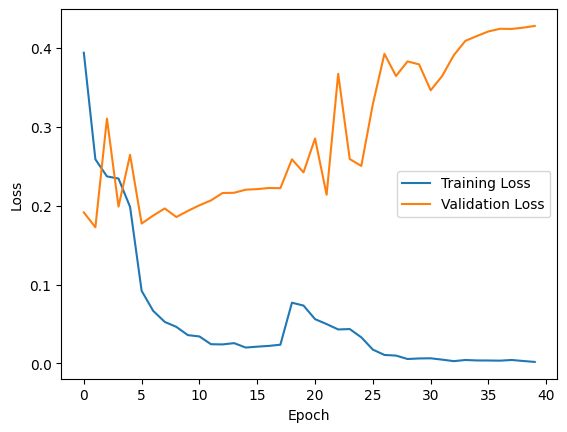

In [ ]:
plt.plot(train_model.training_loss, label='Training Loss')
plt.plot(train_model.validation_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **Test the model**

retrive the best model from the 'best_model.path'

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

def _load_state(path):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)

state = _load_state('best_model.pth')
train_model.model.load_state_dict(state)
print('Loaded best_model.pth into train_model.model (evaluate in the next section).')


Loaded best_model.pth into train_model.model (evaluate in the next section).


# **Model Performance Statements**

calcualte the model performance in term of precision, recall

In [ ]:
# Best model: metrics on held-out TEST
from sklearn.metrics import classification_report, confusion_matrix, f1_score

predicted_labels, _, actual_labels = train_model.test(loader_test, len(test_dataset))
predicted_labels = np.asarray(predicted_labels).flatten()
actual_labels = np.asarray(actual_labels).flatten()

print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(actual_labels, predicted_labels))
print()
print('Classification report:')
print(classification_report(actual_labels, predicted_labels, target_names=dset_classes))
print('Macro F1:', f1_score(actual_labels, predicted_labels, average='macro'))

# Test-time augmentation (optional boost)
print('--- TTA (horizontal flip) ---')
pred_tta, y_tta = train_model.test_tta(loader_test, len(test_dataset), use_hflip=True)
print('TTA report:')
print(classification_report(y_tta, pred_tta, target_names=dset_classes))


Test/Eval — Loss: 0.7377  Acc: 0.9180
Confusion matrix (rows=true, cols=pred):
[[1383   18]
 [ 188  924]]

Classification report:
              precision    recall  f1-score   support

           O       0.88      0.99      0.93      1401
           R       0.98      0.83      0.90      1112

    accuracy                           0.92      2513
   macro avg       0.93      0.91      0.92      2513
weighted avg       0.92      0.92      0.92      2513

Macro F1: 0.9151971467549777
--- TTA (horizontal flip) ---
Test with TTA — Loss: 0.7278  Acc: 0.9232
TTA report:
              precision    recall  f1-score   support

           O       0.89      0.99      0.93      1401
           R       0.98      0.84      0.91      1112

    accuracy                           0.92      2513
   macro avg       0.93      0.91      0.92      2513
weighted avg       0.93      0.92      0.92      2513



The model for benchmarking from [Kaggle](https://www.kaggle.com/code/trushildhokiya/watse-classification-pytorch-modified-lenet/notebook) is using LeNet Network with architecure like following

In [ ]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.model = nn.Sequential(
            # first layer
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            # second layer
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            # third layer
            nn.Flatten(),
            nn.Linear(in_features=29*29*16, out_features=120),
            nn.ReLU(),

            # fourth layer
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(),

            # output layer
            nn.Linear(in_features=84, out_features=2)
        )

    def forward(self, x):
        return self.model(x)

the performance of LeNet is: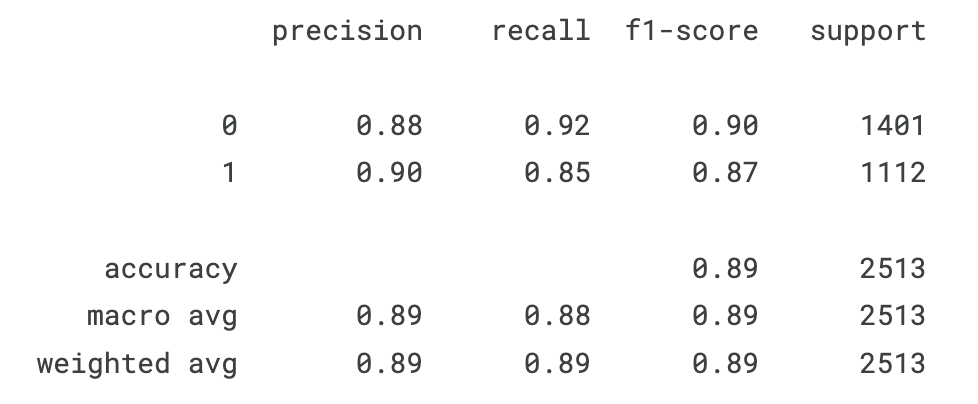

Therefore, our model is outperforming